In [38]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Modeling

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler








In [39]:
from pmdarima import auto_arima

In [40]:
credit_owned = pd.read_csv('CREDIT_OWNED.csv')
personal_expenditure = pd.read_csv('PERSONAL_EXPENDITURE.csv')
saving_rate = pd.read_csv('SAVING_RATE.csv')
disposable_personal_income = pd.read_csv('DSPIC96.csv')
avg_hourly_earnings = pd.read_csv('CES0500000003.csv')
unemployment_rate = pd.read_csv('UNRATE.csv')
federal_funds = pd.read_csv('FEDFUNDS.csv')
food_cpi = pd.read_csv('CPIUFDSL.csv')
cpi = pd.read_csv('CPIAUCSL.csv')
energy_cpi = pd.read_csv('CUSR0000SACE.csv')
shelter_cpi = pd.read_csv('CUSR0000SAH1.csv')
cc_delinquency_rate = pd.read_csv('DRCCLACBS.csv')



In [41]:
for df_ in [credit_owned,
    personal_expenditure,
    saving_rate,
    disposable_personal_income,
    avg_hourly_earnings,
    unemployment_rate,
    federal_funds,
    food_cpi,
    cpi,
    energy_cpi,
    shelter_cpi,
    cc_delinquency_rate]:
    df_["observation_date"] = pd.to_datetime(df_["observation_date"])
    df_.set_index("observation_date", inplace=True)
    df_.sort_index(inplace=True)

   


In [42]:
personal_expenditure = personal_expenditure.rename(columns={"PCEC96": "consumer_spending"})
saving_rate = saving_rate.rename(columns={"PSAVERT": "saving_rate"})
credit_owned = credit_owned.rename(columns={"TOTALSL": "credit_total"})
df = personal_expenditure.join(saving_rate, how="inner").join(credit_owned, how="inner")
display(df.head)
print(personal_expenditure.columns)

<bound method NDFrame.head of                   consumer_spending  saving_rate  credit_total
observation_date                                              
2007-01-01                  11181.0          2.4    2457945.58
2007-02-01                  11178.2          2.8    2470049.92
2007-03-01                  11190.7          3.0    2484433.18
2007-04-01                  11201.5          3.0    2493729.77
2007-05-01                  11218.0          2.8    2510016.06
...                             ...          ...           ...
2025-07-01                  16547.5          4.3    5057212.70
2025-08-01                  16595.8          4.1    5059896.38
2025-09-01                  16614.3          4.0    5071365.99
2025-10-01                  16665.1          3.7    5080601.87
2025-11-01                  16715.4          3.5    5084831.24

[227 rows x 3 columns]>

Index(['consumer_spending'], dtype='object')


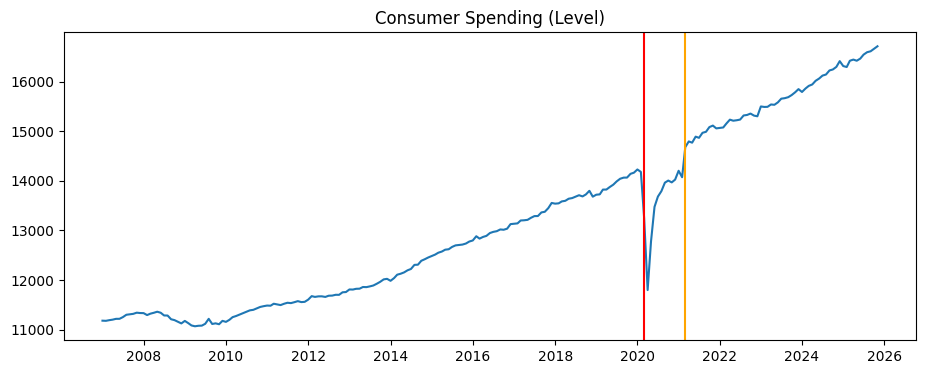

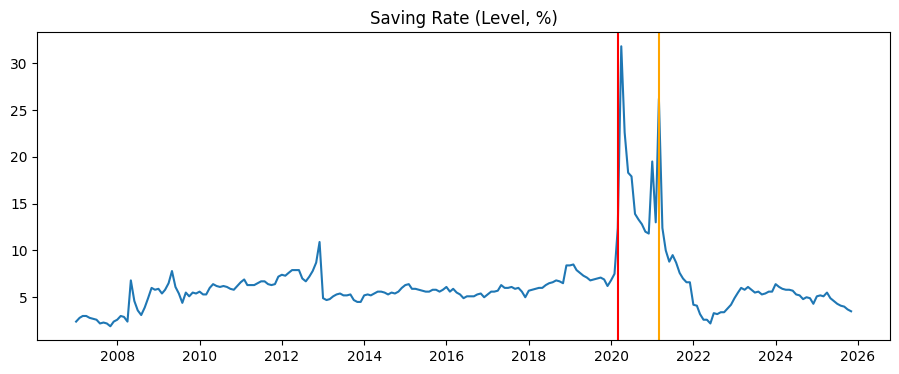

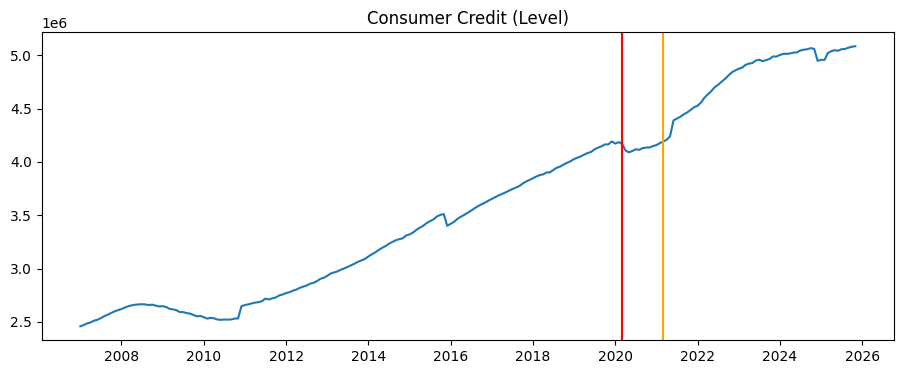

In [43]:
# df["t"] = np.arange(len(df))

# # month seasonality dummies (captures repeating annual patterns)
# df["month"] = df.index.month
# month_dummies = pd.get_dummies(df["month"], prefix="m", drop_first=True)
# df = pd.concat([df.drop(columns=["month"]), month_dummies], axis=1)
# print(df)
# Key dates (for plots + splitting train/test)
covid_start = pd.Timestamp("2020-03-01")
inflation_start = pd.Timestamp("2021-03-01")


def plot_series(col, title=None):
    plt.figure(figsize=(11, 4))
    plt.plot(df.index, df[col])
    plt.axvline(covid_start, color="red")
    plt.axvline(inflation_start, color="orange")
    plt.title(title or col)
    plt.show()

# Levels
plot_series("consumer_spending", "Consumer Spending (Level)")
plot_series("saving_rate", "Saving Rate (Level, %)")
plot_series("credit_total", "Consumer Credit (Level)")

MSE:  962763.97
RMSE: 981.21
MAE:  897.63
R2:   0.018


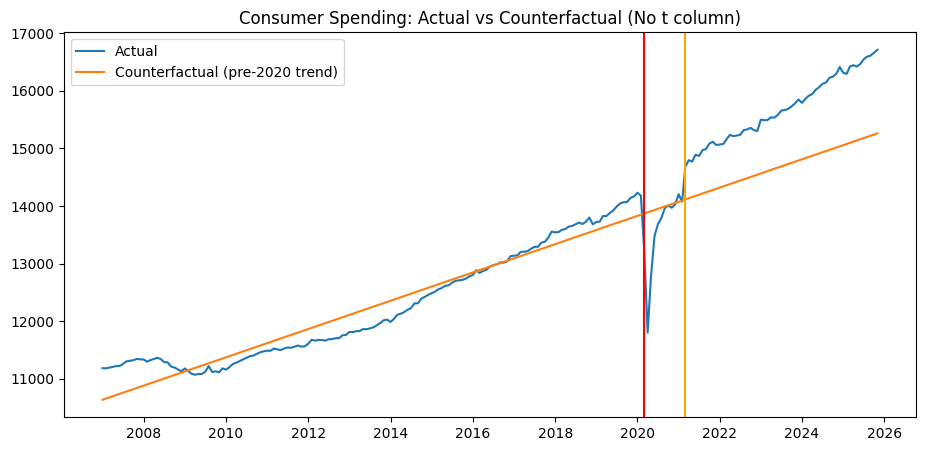

In [44]:
train = df[df.index < covid_start].copy()
test  = df[df.index >= covid_start].copy()

# Create numeric time feature from dates (months since start)
start_date = df.index.min()
time_months_all = ((df.index.year - start_date.year) * 12 + (df.index.month - start_date.month)).to_numpy().reshape(-1, 1)
# print(time_months_all)
# # Same feature but for train only
time_months_train = time_months_all[df.index < covid_start]

# Fit model on pre-COVID spending trend
model = LinearRegression()
model.fit(time_months_train, train["consumer_spending"])
df["spending_pred"] = model.predict(time_months_all)

y_pred = df.loc[test.index, "spending_pred"] 

# Predict counterfactual for entire timeline

mse  = mean_squared_error(test["consumer_spending"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["consumer_spending"], y_pred)
r2   = r2_score(test["consumer_spending"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")
# Plot actual vs counterfactual
plt.figure(figsize=(11, 5))
plt.plot(df.index, df["consumer_spending"], label="Actual")
plt.plot(df.index, df["spending_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Consumer Spending: Actual vs Counterfactual (No t column)")
plt.show()

Consumer Spending (Real personal_expenditure = pd.read_csv('PERSONAL_EXPENDITURE.csv'))

To evaluate whether consumer spending changed after COVID and the inflation shock, a counterfactual linear regression model was trained using pre-2020 data to estimate the expected spending trajectory. When this model was applied to the post-2020 period, it produced a very low coefficient of determination (R² ≈ 0.018), meaning that the historical trend explains only about 1.8% of the variation in post-COVID spending. In addition, the prediction errors were relatively large (RMSE ≈ 981 and MAE ≈ 898), indicating that the model’s forecasts deviated substantially from actual observed spending. These metrics show that post-COVID spending no longer follows its historical trajectory, suggesting a structural change in consumption behavior. Although overall spending remained relatively strong, it behaved differently from what pre-pandemic trends would predict.

MSE:  34.11
RMSE: 5.84
MAE:  4.18
R2:   -0.078


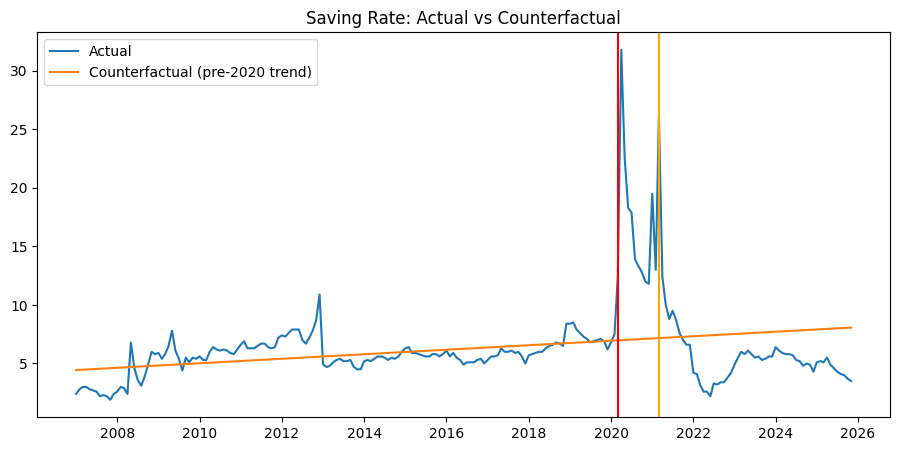

In [45]:
saving_model = LinearRegression()
saving_model.fit(time_months_train, train["saving_rate"])

df["saving_pred"] = saving_model.predict(time_months_all)
y_pred = df.loc[test.index, "saving_pred"] 



mse  = mean_squared_error(test["saving_rate"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["saving_rate"], y_pred)
r2   = r2_score(test["saving_rate"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")

plt.figure(figsize=(11, 5))
plt.plot(df.index, df["saving_rate"], label="Actual")
plt.plot(df.index, df["saving_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Saving Rate: Actual vs Counterfactual")
plt.show()

Personal Saving Rate

The saving rate model reveals an even stronger structural break. A counterfactual model trained on pre-2020 data performs worse than a simple average prediction in the post-COVID period, as indicated by a negative R² value. A negative R² means that the historical trend fails to explain current behavior entirely. The model also produces sizable prediction errors (RMSE ≈ 5.84 and MAE ≈ 4.18), indicating that actual saving rates deviated meaningfully from expected values. This divergence reflects the unusual economic environment: saving_rate surged during the pandemic due to stimulus payments and limited spending opportunities, then fell sharply as inflation eroded purchasing power. The poor model performance confirms that saving behavior experienced a major structural shift.

MSE:  81128976281.97
RMSE: 284831.49
MAE:  246559.97
R2:   0.338


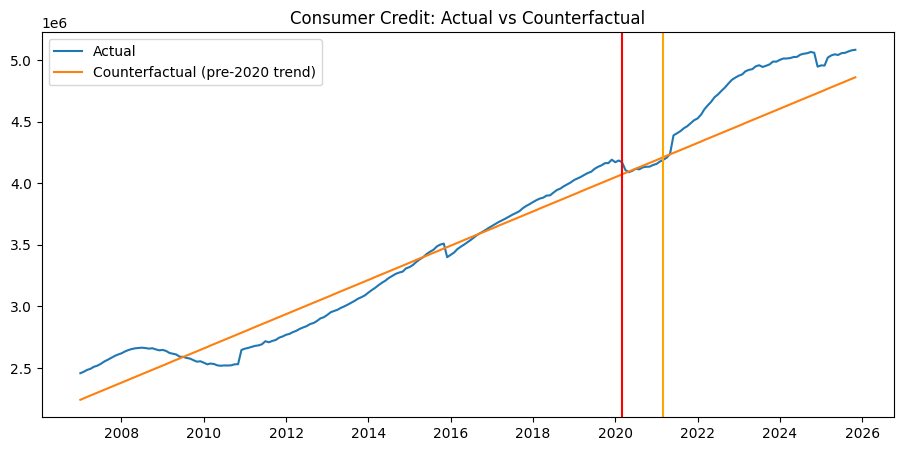

In [46]:

credit_model = LinearRegression()
credit_model.fit(time_months_train, train["credit_total"])

df["credit_pred"] = credit_model.predict(time_months_all)
y_pred = df.loc[test.index, "credit_pred"] 


mse  = mean_squared_error(test["credit_total"], y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(test["credit_total"], y_pred)
r2   = r2_score(test["credit_total"], y_pred)
print(f"MSE:  {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAE:  {mae:.2f}")
print(f"R2:   {r2:.3f}")

plt.figure(figsize=(11, 5))
plt.plot(df.index, df["credit_total"], label="Actual")
plt.plot(df.index, df["credit_pred"], label="Counterfactual (pre-2020 trend)")
plt.axvline(covid_start, color="red")
plt.axvline(inflation_start, color="orange")
plt.legend()
plt.title("Consumer Credit: Actual vs Counterfactual")
plt.show()


Consumer credit_ownedOutstanding

Consumer credit_ownedshows a different pattern compared to spending and saving. The counterfactual model trained on pre-COVID data achieves a moderate explanatory power (R² ≈ 0.338), meaning that about 33.8% of the variation in post-COVID credit_ownedlevels can still be explained by historical trends. While prediction errors exist (RMSE ≈ 284,831 and MAE ≈ 246,559), the model performs substantially better than in the spending and saving cases. This suggests that borrowing behavior continued along a partially predictable upward trajectory even after the inflation shock. The continued growth of credit, despite rising interest rates, implies that households increasingly relied on borrowing to maintain consumption as saving_rate declined.

Using a counterfactual model trained only on pre-March 2020 data, we compared observed post-inflation behavior to what would have been expected had historical trends continued unchanged. The results suggest a meaningful structural shift in household financial behavior. Real consumer spending recovered and remains modestly above its pre-COVID trend, indicating that aggregate consumption did not collapse permanently. However, the personal saving rate has remained significantly below its historical trajectory, suggesting households are saving structurally less than expected. At the same time, consumer credit_ownedlevels are persistently above their pre-2020 trend, indicating increased reliance on borrowing. Taken together, these patterns imply that while spending itself returned toward trend, the way households finance consumption has shifted—characterized by lower saving_rate buffers and higher credit_ownedusage—pointing to a lasting behavioral adjustment rather than a purely temporary disruption.

In [47]:
# cpi = pd.read_csv("CPIAUCSL.csv")
# federal_funds = pd.read_csv("FEDFUNDS.csv")
# disposable_personal_income = pd.read_csv("DSPIC96.csv")
# unemployment_rate = pd.read_csv("UNRATE.csv")
# cc_delinquency_rate = pd.read_csv("DRCCLACBS.csv")

In [48]:
cpi = cpi.rename(columns={
    "observation_date": "date",
    "CPIAUCSL": "inflation_index"
})

federal_funds = federal_funds.rename(columns={
    "observation_date": "date",
    "FEDFUNDS": "fed_funds_rate"
})

disposable_personal_income = disposable_personal_income.rename(columns={
    "observation_date": "date",
    "DSPIC96": "real_disposable_income"
})

unemployment_rate = unemployment_rate.rename(columns={
    "observation_date": "date",
    "UNRATE": "unemployment_rate"
})


food_cpi = food_cpi.rename(columns={
    "observation_date": "date",
    "CPIUFDSL": "food_cpi"
})

energy_cpi = energy_cpi.rename(columns={
    "observation_date": "date",
    "CUSR0000SACE": "energy_cpi"
})

shelter_cpi = shelter_cpi.rename(columns={
    "observation_date": "date",
    "CUSR0000SAH1": "shelter_cpi"
})

avg_hourly_earnings = avg_hourly_earnings.rename(columns={
    "observation_date": "date",
    "CES0500000003": "avg_hourly_earnings"
})

cc_delinquency_rate = cc_delinquency_rate.rename(columns={
    "observation_date": "date",
    "DRCCLACBS": "cc_delinquency_rate"
})

In [49]:
# print(cpi)
df_behavior = df.copy()

df_merged = (
    personal_expenditure
    .join(saving_rate, how="inner")
    .join(credit_owned, how="inner")
    .join(cpi, how="inner")
    .join(federal_funds, how="inner")
    .join(disposable_personal_income, how="inner")
    .join(unemployment_rate, how="inner")
    .join(food_cpi, how="inner")
    .join(energy_cpi, how="inner")
    .join(shelter_cpi, how="inner")
    .join(avg_hourly_earnings, how="inner")
    .join(cc_delinquency_rate, how="inner")
)

print(df_merged.columns)
print(df_merged)

Index(['consumer_spending', 'saving_rate', 'credit_total', 'inflation_index',
       'fed_funds_rate', 'real_disposable_income', 'unemployment_rate',
       'food_cpi', 'energy_cpi', 'shelter_cpi', 'avg_hourly_earnings',
       'cc_delinquency_rate'],
      dtype='object')
                  consumer_spending  saving_rate  credit_total  \
observation_date                                                 
2007-01-01                  11181.0          2.4    2457945.58   
2007-04-01                  11201.5          3.0    2493729.77   
2007-07-01                  11252.6          2.6    2533667.67   
2007-10-01                  11318.6          2.2    2582326.03   
2008-01-01                  11333.2          2.6    2619427.65   
...                             ...          ...           ...   
2024-10-01                  16247.7          5.0    5067276.20   
2025-01-01                  16316.5          5.1    4957979.27   
2025-04-01                  16446.9          5.5    5038854.01   


In [50]:
print(df_merged.columns)

Index(['consumer_spending', 'saving_rate', 'credit_total', 'inflation_index',
       'fed_funds_rate', 'real_disposable_income', 'unemployment_rate',
       'food_cpi', 'energy_cpi', 'shelter_cpi', 'avg_hourly_earnings',
       'cc_delinquency_rate'],
      dtype='object')


In [51]:
df_clean = df_merged.dropna()
X_spending = df_clean[[
    "inflation_index",
    "real_disposable_income",
    "unemployment_rate"
]]

y_spending = df_clean["consumer_spending"]

X_saving = df_clean[[
    "inflation_index",
    "real_disposable_income"
]]

y_saving = df_clean["saving_rate"]

X_credit_owned= df_clean[[
    "fed_funds_rate",
    "real_disposable_income"
]]

y_credit_owned= df_clean["credit_total"]

In [52]:
spending_model = LinearRegression()
spending_model.fit(X_spending, y_spending)

saving_model = LinearRegression()
saving_model.fit(X_saving, y_saving)

credit_model = LinearRegression()
credit_model.fit(X_credit_owned, y_credit_owned)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [53]:
spending_coef = pd.Series(spending_model.coef_, index=X_spending.columns)
saving_coef = pd.Series(saving_model.coef_, index=X_saving.columns)
credit_coef = pd.Series(credit_model.coef_, index=X_credit_owned.columns)

print("Spending coefficients")
print(spending_coef)




Spending coefficients
inflation_index            29.584697
real_disposable_income      0.260743
unemployment_rate        -159.748303
dtype: float64


The results suggest that consumer spending rises with higher inflation and higher disposable income but falls when unemployment increases. During the COVID period, inflation rose sharply while incomes were supported by stimulus and a strong labor market, which helped keep spending relatively high. At the same time, unemployment pressures tend to reduce spending, so changes in the labor market remain an important factor influencing consumer demand.

In [54]:
print("\nSaving coefficients")
print(saving_coef)


Saving coefficients
inflation_index          -0.238885
real_disposable_income    0.004391
dtype: float64


These coefficients show how inflation and income relate to the personal saving rate. The negative coefficient for the inflation index (-0.21) suggests that when inflation increases, the saving rate tends to decrease. This likely reflects the post-COVID environment where rising prices forced households to spend more of their income on necessities, leaving less available to save. The coefficient for real disposable income (0.0039) is positive but very small, indicating that increases in income slightly raise the saving rate, though the effect is relatively weak compared to the impact of inflation. Overall, the model suggests that inflation plays a stronger role in shaping saving behavior than income changes during this period.

In [55]:
print("\ncredit_owned coefficients")
print(credit_coef)


credit_owned coefficients
fed_funds_rate            49106.249827
real_disposable_income      393.977824
dtype: float64


These coefficients indicate how borrowing behavior responds to interest rates and income. The large positive coefficient for the federal funds rate (46321.38) suggests that as interest rates rise, the level of consumer credit_ownedoutstanding also increases. This may reflect the post-COVID period when households continued borrowing despite higher rates, possibly due to higher living costs and inflationary pressure. The positive coefficient for real disposable income (398.44) shows that higher income is associated with slightly greater borrowing, as households with more income may feel more comfortable taking on credit. Overall, the model suggests that both rising interest rates and income are associated with higher consumer credit_ownedlevels during this period.

In [56]:
print(df_clean.columns)

Index(['consumer_spending', 'saving_rate', 'credit_total', 'inflation_index',
       'fed_funds_rate', 'real_disposable_income', 'unemployment_rate',
       'food_cpi', 'energy_cpi', 'shelter_cpi', 'avg_hourly_earnings',
       'cc_delinquency_rate'],
      dtype='object')


In [57]:
# After 2008 Crisis
start_date = '2010-01-01' 
covid_start = '2020-03-01'
covid_end = '2023-07-01'

# Cut out all data before start_date
df_clean = df_clean[df_clean.index >= pd.Timestamp(start_date)]
if 'date' in df_clean.columns:
    df_clean = df_clean.set_index('date')

# Set era for each row
def era_group(date):
    """
    The function categorizes each date into pre-covid, covid/inflation shock, post-shock era
    """
    if date < pd.Timestamp(covid_start):
        return 'Pre-COVID'
    elif date < pd.Timestamp(covid_end):
        return 'COVID/Inflation Shock'
    else:
        return 'Post-Shock'
        
df_clean['era'] = df_clean.index.map(era_group)

# Color map for eras
ERA_COLORS = {
    'Pre-COVID': '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock': '#4CAF50'
}

print(df_clean['era'].value_counts())

era
Pre-COVID                41
COVID/Inflation Shock    13
Post-Shock                9
Name: count, dtype: int64


In [58]:
#Plot with colored era
COVID_START = pd.Timestamp('2020-03-01')    # WHO pandemic declaration
INFLATION_PEAK = pd.Timestamp('2022-06-01') # CPI-U peak at 9.1% YoY
RATE_HIKE_START = pd.Timestamp('2022-03-01') # First Fed rate hike
def plot_with_era(series, title, ylabel, ax=None, show_trend=True):
    """Plot a time series with colored era shading."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(14, 5))
    
    # era shading
    ax.axvspan(df_clean.index.min(), pd.Timestamp('2020-02-01'),
               alpha=0.08, color=ERA_COLORS['Pre-COVID'], label='Pre-COVID')
    ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
               alpha=0.08, color=ERA_COLORS['COVID/Inflation Shock'], label='COVID/Inflation')
    ax.axvspan(pd.Timestamp('2023-07-01'), df_clean.index.max(),
               alpha=0.08, color=ERA_COLORS['Post-Shock'], label='Post-Shock')
    
    # Key event lines
    ax.axvline(COVID_START, color='red', ls='--', lw=1, alpha=0.7)
    ax.axvline(INFLATION_PEAK, color='orange', ls='--', lw=1, alpha=0.7)
    ax.axvline(RATE_HIKE_START, color='purple', ls='--', lw=1, alpha=0.7)
    
    # Data
    data = series.dropna()
    ax.plot(data.index, data.values, color='#333333', lw=1.5)
    
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper left', fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    return ax

In [59]:
print(df_clean.columns)

Index(['consumer_spending', 'saving_rate', 'credit_total', 'inflation_index',
       'fed_funds_rate', 'real_disposable_income', 'unemployment_rate',
       'food_cpi', 'energy_cpi', 'shelter_cpi', 'avg_hourly_earnings',
       'cc_delinquency_rate', 'era'],
      dtype='object')


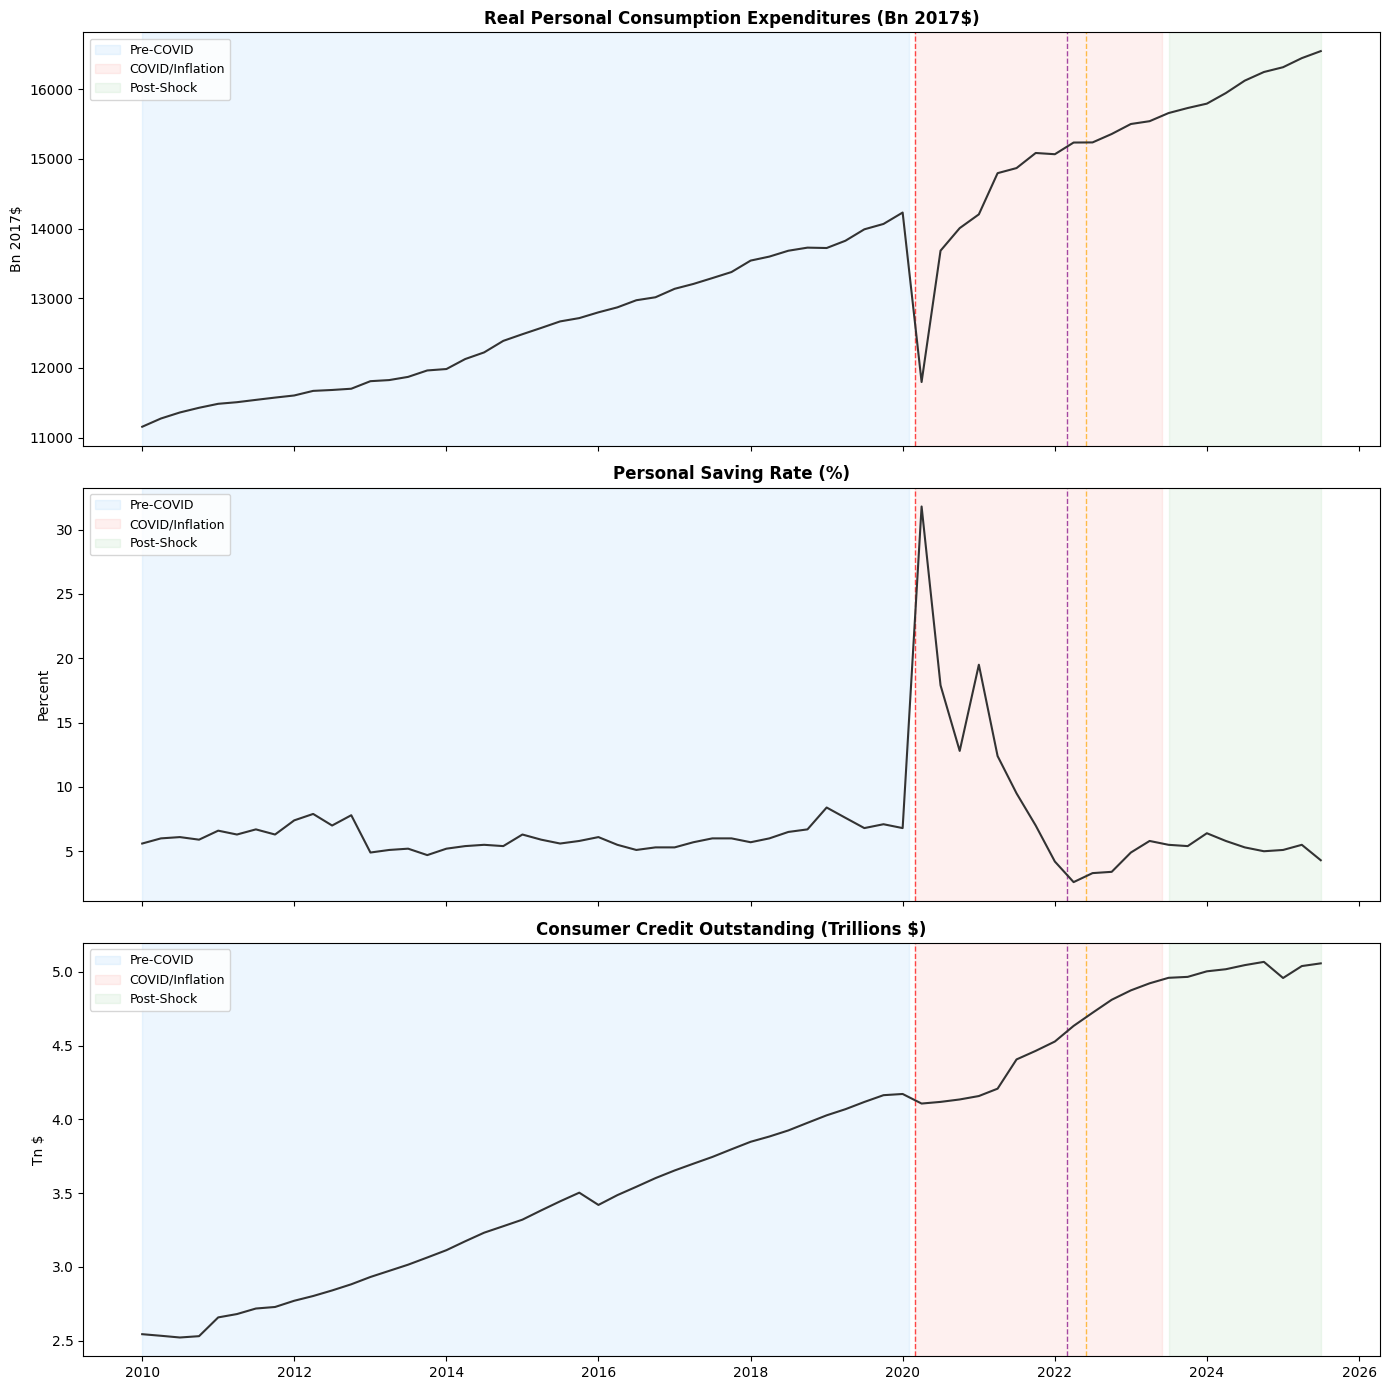

In [60]:
#Plot Credit Owned, Saving Rate, Personal Expenditure
fig, axes = plt.subplots(3, 1, figsize=(14, 14), sharex=True)

plot_with_era(df_clean['consumer_spending'], 
    'Real Personal Consumption Expenditures (Bn 2017$)', 'Bn 2017$', axes[0])

plot_with_era(df_clean['saving_rate'], 
    'Personal Saving Rate (%)', 'Percent', axes[1])

plot_with_era(df_clean['credit_total'] / 1e6, 
    'Consumer Credit Outstanding (Trillions $)', 'Tn $', axes[2])

plt.tight_layout()
plt.show()

In [61]:
print(df_clean.columns)

Index(['consumer_spending', 'saving_rate', 'credit_total', 'inflation_index',
       'fed_funds_rate', 'real_disposable_income', 'unemployment_rate',
       'food_cpi', 'energy_cpi', 'shelter_cpi', 'avg_hourly_earnings',
       'cc_delinquency_rate', 'era'],
      dtype='object')


In [62]:
# Calculate YoY and MoM change
df_clean['pe_yoy'] = df_clean['consumer_spending'].pct_change(12) * 100
df_clean['pe_mom'] = df_clean['consumer_spending'].pct_change(1) * 100
df_clean['credit_yoy'] = df_clean['credit_total'].pct_change(12) * 100
df_clean['credit_mom'] = df_clean['credit_total'].pct_change(1) * 100
df_clean['hourly_wage_yoy'] = df_clean['avg_hourly_earnings'].pct_change(12) * 100
df_clean['income_yoy'] = df_clean['real_disposable_income'].pct_change(12) * 100
df_clean['cpi_yoy'] = df_clean['inflation_index'].pct_change(12) * 100
df_clean['food_cpi_yoy'] = df_clean['food_cpi'].pct_change(12) * 100
df_clean['energy_cpi_yoy'] = df_clean['energy_cpi'].pct_change(12) * 100
df_clean['shelter_cpi_yoy'] = df_clean['shelter_cpi'].pct_change(12) * 100

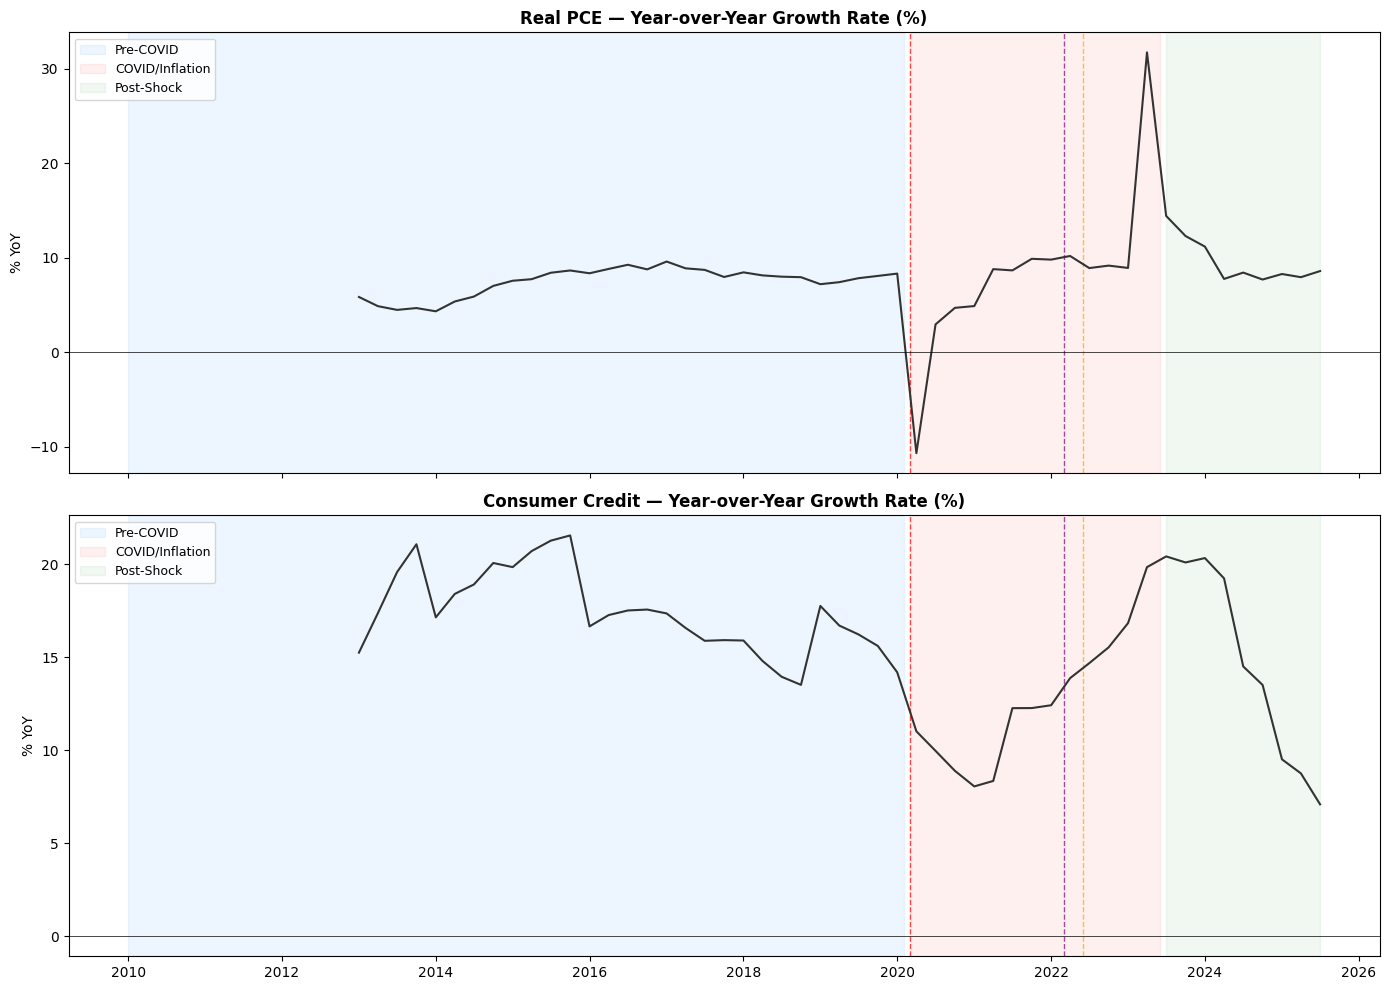

In [63]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

plot_with_era(df_clean['pe_yoy'], 
    'Real PCE — Year-over-Year Growth Rate (%)', '% YoY', axes[0])
axes[0].axhline(0, color='black', lw=0.5)

plot_with_era(df_clean['credit_yoy'], 
    'Consumer Credit — Year-over-Year Growth Rate (%)', '% YoY', axes[1])
axes[1].axhline(0, color='black', lw=0.5)

plt.tight_layout()
plt.show()

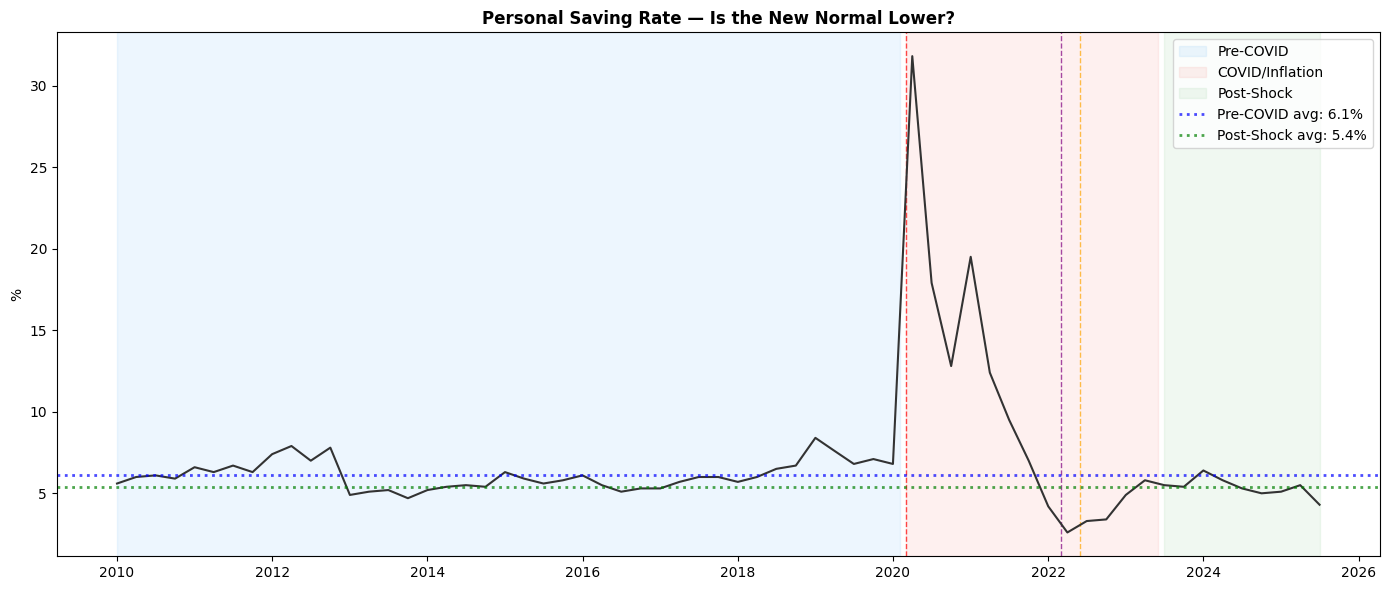

In [64]:
fig, ax = plt.subplots(figsize=(14, 6))
sr = df_clean['saving_rate'].dropna()

# Pre-COVID average
pre_covid_mean = sr.loc[:COVID_START].mean()
post_shock_mean = sr.loc['2023-07-01':].mean()

plot_with_era(sr, 'Personal Saving Rate — Is the New Normal Lower?', '%', ax)

ax.axhline(pre_covid_mean, color='blue', ls=':', lw=2, alpha=0.7, 
           label=f'Pre-COVID avg: {pre_covid_mean:.1f}%')
ax.axhline(post_shock_mean, color='green', ls=':', lw=2, alpha=0.7, 
           label=f'Post-Shock avg: {post_shock_mean:.1f}%')
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [65]:
#Build the Model
START_DATE       = '2010-01-01'
COVID_START      = '2020-03-01'
COVID_END        = '2023-07-01'
TRAIN_END        = '2020-02-01'        # Last month of "normal" for training
SEASONAL_PERIOD  = 12                   # Monthly data

ERA_COLORS = {
    'Pre-COVID':             '#2196F3',
    'COVID/Inflation Shock': '#F44336',
    'Post-Shock':            '#4CAF50'
}

# The 3 core target series from the project brief
TARGETS = {
    'consumer_spending': {
        'label': 'Real Personal Consumption Expenditures',
        'unit':  'Bn 2017$'
    },
    'saving_rate': {
        'label': 'Personal Saving Rate',
        'unit':  '%'
    },
    'credit_total': {
        'label': 'Consumer Credit Outstanding',
        'unit':  'Mn $'
    }
}

# Exogenous features to feed into SARIMAX
EXOG_FEATURES = [
    'cpi', 'federal_funds', 'unemployment_rate',
    'disposable_personal_income', 'avg_hourly_earnings'
]

def build_counterfactual_model(df, target_col, exog_cols=None):
    train_mask = df_clean.index <= pd.Timestamp(TRAIN_END)
    post_mask  = df_clean.index > pd.Timestamp(TRAIN_END)

    y_train = df_clean.loc[train_mask, target_col].dropna()
    y_post  = df_clean.loc[post_mask, target_col].dropna()

    # Exogenous variables
    X_train, X_post = None, None
    if exog_cols:
        available_exog = [c for c in exog_cols if c in df_clean.columns and c != target_col]
        if available_exog:
            scaler = StandardScaler()
            X_all = df_clean[available_exog].interpolate(method='time').ffill().bfill()
            X_all[available_exog] = scaler.fit_transform(X_all[available_exog])

            X_train = X_all.loc[y_train.index]
            X_post  = X_all.loc[y_post.index]

    # Auto ARIMA
    print(f"Fitting auto_arima for: {target_col}")
    print(f"Training period: {y_train.index[0].strftime('%Y-%m')} → {y_train.index[-1].strftime('%Y-%m')}")
    print(f"Forecast period: {y_post.index[0].strftime('%Y-%m')} → {y_post.index[-1].strftime('%Y-%m')}")
    if X_train is not None:
        print(f"  Exogenous features: {available_exog}")

    auto_model = auto_arima(
        y_train,
        X=X_train,
        seasonal=True,
        m=SEASONAL_PERIOD,
        stepwise=True,
        suppress_warnings=True,
        trace=False,
        error_action='ignore',
        max_p=3, max_q=3,
        max_P=2, max_Q=2,
        max_d=2, max_D=1,
        information_criterion='aic',
        n_fits=50
    )

    order = auto_model.order
    seasonal_order = auto_model.seasonal_order
    aic = auto_model.aic()

    print(f"Best order: ARIMA{order} x {seasonal_order}")
    print(f"AIC: {aic:.2f}")

    # Counterfactual forecast
    n_forecast = len(y_post)
    forecast, conf_int = auto_model.predict(
        n_periods=n_forecast,
        X=X_post,
        return_conf_int=True,
        alpha=0.05      # 95% CI
    )

    forecast_df = pd.DataFrame({
        'counterfactual':  forecast,
        'lower_ci':        conf_int[:, 0],
        'upper_ci':        conf_int[:, 1],
        'actual':          y_post.values
    }, index=y_post.index)

    # Gap = actual - counterfactual
    forecast_df['gap']     = forecast_df['actual'] - forecast_df['counterfactual']
    forecast_df['gap_pct'] = (forecast_df['gap'] / forecast_df['counterfactual']) * 100

    return {
        'model':          auto_model,
        'forecast_df':    forecast_df,
        'y_train':        y_train,
        'order':          order,
        'seasonal_order': seasonal_order,
        'aic':            aic,
        'exog_used':      available_exog if X_train is not None else []
    }

In [66]:
def run_all_models(df_clean):
    """Build counterfactual models for all 3 core targets."""
    print(" AUTO-SARIMAX COUNTERFACTUAL MODELING")

    models = {}
    for col in TARGETS:
        models[col] = build_counterfactual_model(
            df_clean, col, exog_cols=EXOG_FEATURES
        )
    return models

In [67]:
def gap_analysis(models, df_clean):
    """Compute summary statistics for actual vs counterfactual gaps."""
    print(" GAP ANALYSIS — ACTUAL vs COUNTERFACTUAL")

    for col, meta in TARGETS.items():
        fdf = models[col]['forecast_df']

        # Split gap into COVID era and post-shock era
        covid_gap = fdf.loc[
            (fdf.index >= pd.Timestamp(COVID_START)) &
            (fdf.index < pd.Timestamp(COVID_END)), 'gap_pct'
        ]
        post_gap = fdf.loc[
            fdf.index >= pd.Timestamp(COVID_END), 'gap_pct'
        ]

        print(f"\n  {meta['label']}  ({meta['unit']})")
        print(f"Model: ARIMA{models[col]['order']} x {models[col]['seasonal_order']}")
        print(f"AIC: {models[col]['aic']:.2f}")
        print(f"Exogenous: {models[col]['exog_used']}")
        print(f"COVID/Inflation period mean gap: {covid_gap.mean():+.2f}%")
        print(f"Post-Shock period mean gap:      {post_gap.mean():+.2f}%")
        print(f"Latest gap ({fdf.index[-1].strftime('%Y-%m')}):        {fdf['gap_pct'].iloc[-1]:+.2f}%")

        # Is the gap converging?
        if len(post_gap) >= 6:
            recent = post_gap.iloc[-6:].mean()
            earlier = post_gap.iloc[:6].mean()
            if abs(recent) < abs(earlier) * 0.5:
                print(f"Trend: GAP CONVERGING (temporary disruption)")
            elif abs(recent) > abs(earlier):
                print(f"Trend: GAP WIDENING (structural shift)")
            else:
                print(f"Trend: GAP PERSISTENT (possible structural change)")

In [68]:
def plot_counterfactual(models, df_clean, breaks_dict):
    """
    Create a 3-panel figure showing actual vs counterfactual
    for each core indicator, with structural breaks marked.
    """
    fig, axes = plt.subplots(3, 1, figsize=(16, 16))
    fig.suptitle(
        'Has Inflation Permanently Changed Consumer Behaviour?\n'
        'Actual vs. Counterfactual (Pre-COVID SARIMAX Forecast)',
        fontsize=16, fontweight='bold', y=1.01
    )

    for idx, (col, meta) in enumerate(TARGETS.items()):
        ax = axes[idx]
        result = models[col]
        fdf = result['forecast_df']
        y_train = result['y_train']

        # Era shading
        ax.axvspan(df_clean.index.min(), pd.Timestamp('2020-02-01'),
                   alpha=0.06, color=ERA_COLORS['Pre-COVID'])
        ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2023-06-01'),
                   alpha=0.06, color=ERA_COLORS['COVID/Inflation Shock'])
        ax.axvspan(pd.Timestamp('2023-07-01'), df_clean.index.max(),
                   alpha=0.06, color=ERA_COLORS['Post-Shock'])

        # Training data
        ax.plot(y_train.index, y_train.values,
                color='#333', lw=1.5, label='Actual (training)')

        # Actual post-COVID
        ax.plot(fdf.index, fdf['actual'],
                color='#333', lw=2, label='Actual (observed)')

        # Counterfactual forecast
        ax.plot(fdf.index, fdf['counterfactual'],
                color='#E65100', lw=2, ls='--',
                label='Counterfactual (no-shock forecast)')

        # 95% confidence interval
        ax.fill_between(fdf.index,
                        fdf['lower_ci'], fdf['upper_ci'],
                        alpha=0.15, color='#E65100',
                        label='95% CI')

        # Shade the gap
        ax.fill_between(fdf.index,
                        fdf['actual'], fdf['counterfactual'],
                        where=fdf['actual'] > fdf['counterfactual'],
                        alpha=0.2, color='green', label='Above baseline')
        ax.fill_between(fdf.index,
                        fdf['actual'], fdf['counterfactual'],
                        where=fdf['actual'] < fdf['counterfactual'],
                        alpha=0.2, color='red', label='Below baseline')

        # Structural breaks
        if col in breaks_dict:
            for bdate in breaks_dict[col]:
                ax.axvline(bdate, color='magenta', ls=':', lw=2, alpha=0.8)
            if breaks_dict[col]:
                ax.axvline(breaks_dict[col][0], color='magenta', ls=':', lw=2,
                           alpha=0.8, label='Structural break')

        # COVID line
        ax.axvline(pd.Timestamp(COVID_START), color='red', ls='--', lw=1, alpha=0.5)

        ax.set_title(f"{meta['label']}  —  ARIMA{result['order']} x {result['seasonal_order']}",
                     fontsize=12, fontweight='bold')
        ax.set_ylabel(meta['unit'])
        ax.legend(loc='upper left', fontsize=8, ncol=2)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [69]:
def plot_gap_over_time(models):
    """Plot the percentage gap over time for each indicator."""
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(
        'Gap Analysis: How Far Is Reality From the No-Shock Baseline?',
        fontsize=15, fontweight='bold', y=1.01
    )

    for idx, (col, meta) in enumerate(TARGETS.items()):
        ax = axes[idx]
        fdf = models[col]['forecast_df']

        gap = fdf['gap_pct']
        colors = ['green' if g >= 0 else 'red' for g in gap]

        ax.bar(gap.index, gap.values, width=25, color=colors, alpha=0.6)
        ax.axhline(0, color='black', lw=1)

        # Rolling average trend
        rolling = gap.rolling(6).mean()
        ax.plot(rolling.index, rolling.values, color='#333', lw=2,
                label='6-month rolling avg')

        # Era dividers
        ax.axvline(pd.Timestamp(COVID_START), color='red', ls='--', lw=1, alpha=0.5)
        ax.axvline(pd.Timestamp(COVID_END), color='green', ls='--', lw=1, alpha=0.5)

        ax.set_title(f"{meta['label']} — % Deviation from Counterfactual", fontweight='bold')
        ax.set_ylabel('Gap (%)')
        ax.legend(fontsize=9)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    plt.tight_layout()
    plt.show()

In [70]:
def print_model_summary(models):
    """Print concise diagnostics for each fitted model."""
    print(" MODEL DIAGNOSTICS SUMMARY")

    summary_rows = []
    for col, meta in TARGETS.items():
        m = models[col]
        summary_rows.append({
            'Indicator':       meta['label'],
            'Order':           f"ARIMA{m['order']}",
            'Seasonal':        f"{m['seasonal_order']}",
            'AIC':             round(m['aic'], 2),
            'Exog Features':   len(m['exog_used']),
            'Train Obs':       len(m['y_train']),
            'Forecast Obs':    len(m['forecast_df'])
        })

    summary_df = pd.DataFrame(summary_rows)
    print(summary_df.to_string(index=False))
    return summary_df

In [71]:
def plot_residual_diagnostics(models):
    """Plot residuals for each model to check assumptions."""
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle('Residual Diagnostics', fontsize=14, fontweight='bold')

    for idx, (col, meta) in enumerate(TARGETS.items()):
        resid = models[col]['model'].resid()

        # Residual time series
        axes[idx, 0].plot(resid, color='#333', lw=0.8)
        axes[idx, 0].axhline(0, color='red', ls='--', lw=1)
        axes[idx, 0].set_title(f'{meta["label"]} — Residuals', fontsize=10)
        axes[idx, 0].set_ylabel('Residual')

        # Histogram
        axes[idx, 1].hist(resid, bins=30, color='#2196F3', alpha=0.7, edgecolor='white')
        axes[idx, 1].set_title(f'{meta["label"]} — Distribution', fontsize=10)
        axes[idx, 1].axvline(0, color='red', ls='--')

    plt.tight_layout()
    plt.show()

In [72]:
print(df_clean.columns)

Index(['consumer_spending', 'saving_rate', 'credit_total', 'inflation_index',
       'fed_funds_rate', 'real_disposable_income', 'unemployment_rate',
       'food_cpi', 'energy_cpi', 'shelter_cpi', 'avg_hourly_earnings',
       'cc_delinquency_rate', 'era', 'pe_yoy', 'pe_mom', 'credit_yoy',
       'credit_mom', 'hourly_wage_yoy', 'income_yoy', 'cpi_yoy',
       'food_cpi_yoy', 'energy_cpi_yoy', 'shelter_cpi_yoy'],
      dtype='object')


In [73]:
print('Fit the Model')
models = run_all_models(df_clean)

Fit the Model
 AUTO-SARIMAX COUNTERFACTUAL MODELING
Fitting auto_arima for: consumer_spending
Training period: 2010-01 → 2020-01
Forecast period: 2020-04 → 2025-07
  Exogenous features: ['unemployment_rate', 'avg_hourly_earnings']
Best order: ARIMA(0, 0, 0) x (0, 0, 0, 12)
AIC: 476.50
Fitting auto_arima for: saving_rate
Training period: 2010-01 → 2020-01
Forecast period: 2020-04 → 2025-07
  Exogenous features: ['unemployment_rate', 'avg_hourly_earnings']
Best order: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 89.37
Fitting auto_arima for: credit_total
Training period: 2010-01 → 2020-01
Forecast period: 2020-04 → 2025-07
  Exogenous features: ['unemployment_rate', 'avg_hourly_earnings']
Best order: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 1162.46


In [74]:
print("Find the difference between actual and counterfactual")
gap_analysis(models, df_clean)

Find the difference between actual and counterfactual
 GAP ANALYSIS — ACTUAL vs COUNTERFACTUAL

  Real Personal Consumption Expenditures  (Bn 2017$)
Model: ARIMA(0, 0, 0) x (0, 0, 0, 12)
AIC: 476.50
Exogenous: ['unemployment_rate', 'avg_hourly_earnings']
COVID/Inflation period mean gap: -4.13%
Post-Shock period mean gap:      -5.87%
Latest gap (2025-07):        -6.28%
Trend: GAP WIDENING (structural shift)

  Personal Saving Rate  (%)
Model: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 89.37
Exogenous: ['unemployment_rate', 'avg_hourly_earnings']
COVID/Inflation period mean gap: +22.59%
Post-Shock period mean gap:      -41.83%
Latest gap (2025-07):        -56.20%
Trend: GAP WIDENING (structural shift)

  Consumer Credit Outstanding  (Mn $)
Model: ARIMA(1, 0, 0) x (0, 0, 0, 12)
AIC: 1162.46
Exogenous: ['unemployment_rate', 'avg_hourly_earnings']
COVID/Inflation period mean gap: -346.12%
Post-Shock period mean gap:      -186.20%
Latest gap (2025-07):        -158.93%
Trend: GAP PERSISTENT (possibl

In [75]:
print("Model diagnostics")
summary = print_model_summary(models)


Model diagnostics
 MODEL DIAGNOSTICS SUMMARY
                             Indicator          Order      Seasonal     AIC  Exog Features  Train Obs  Forecast Obs
Real Personal Consumption Expenditures ARIMA(0, 0, 0) (0, 0, 0, 12)  476.50              2         41            22
                  Personal Saving Rate ARIMA(1, 0, 0) (0, 0, 0, 12)   89.37              2         41            22
           Consumer Credit Outstanding ARIMA(1, 0, 0) (0, 0, 0, 12) 1162.46              2         41            22


Visualization


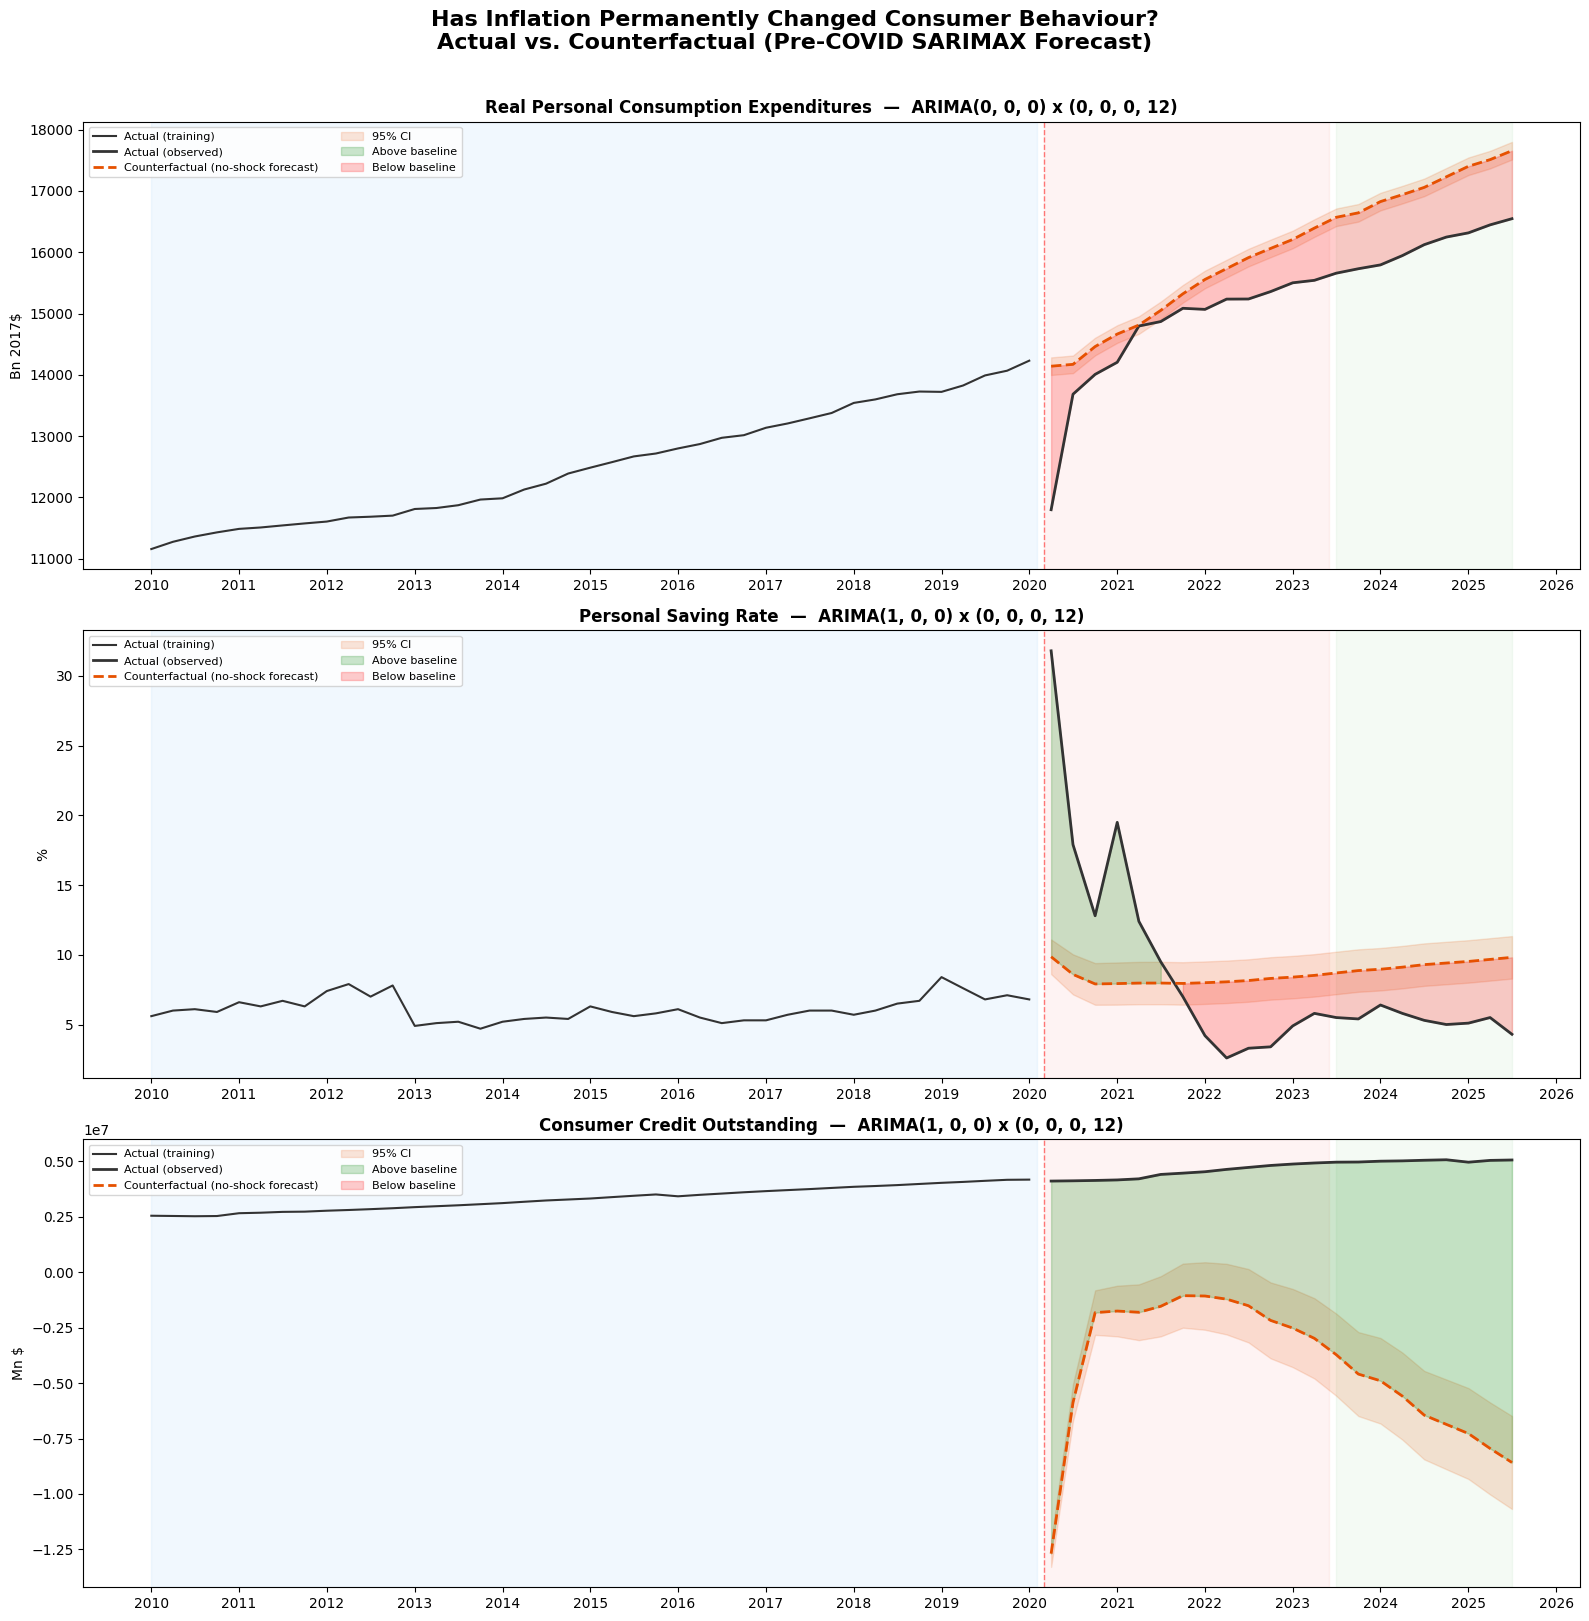

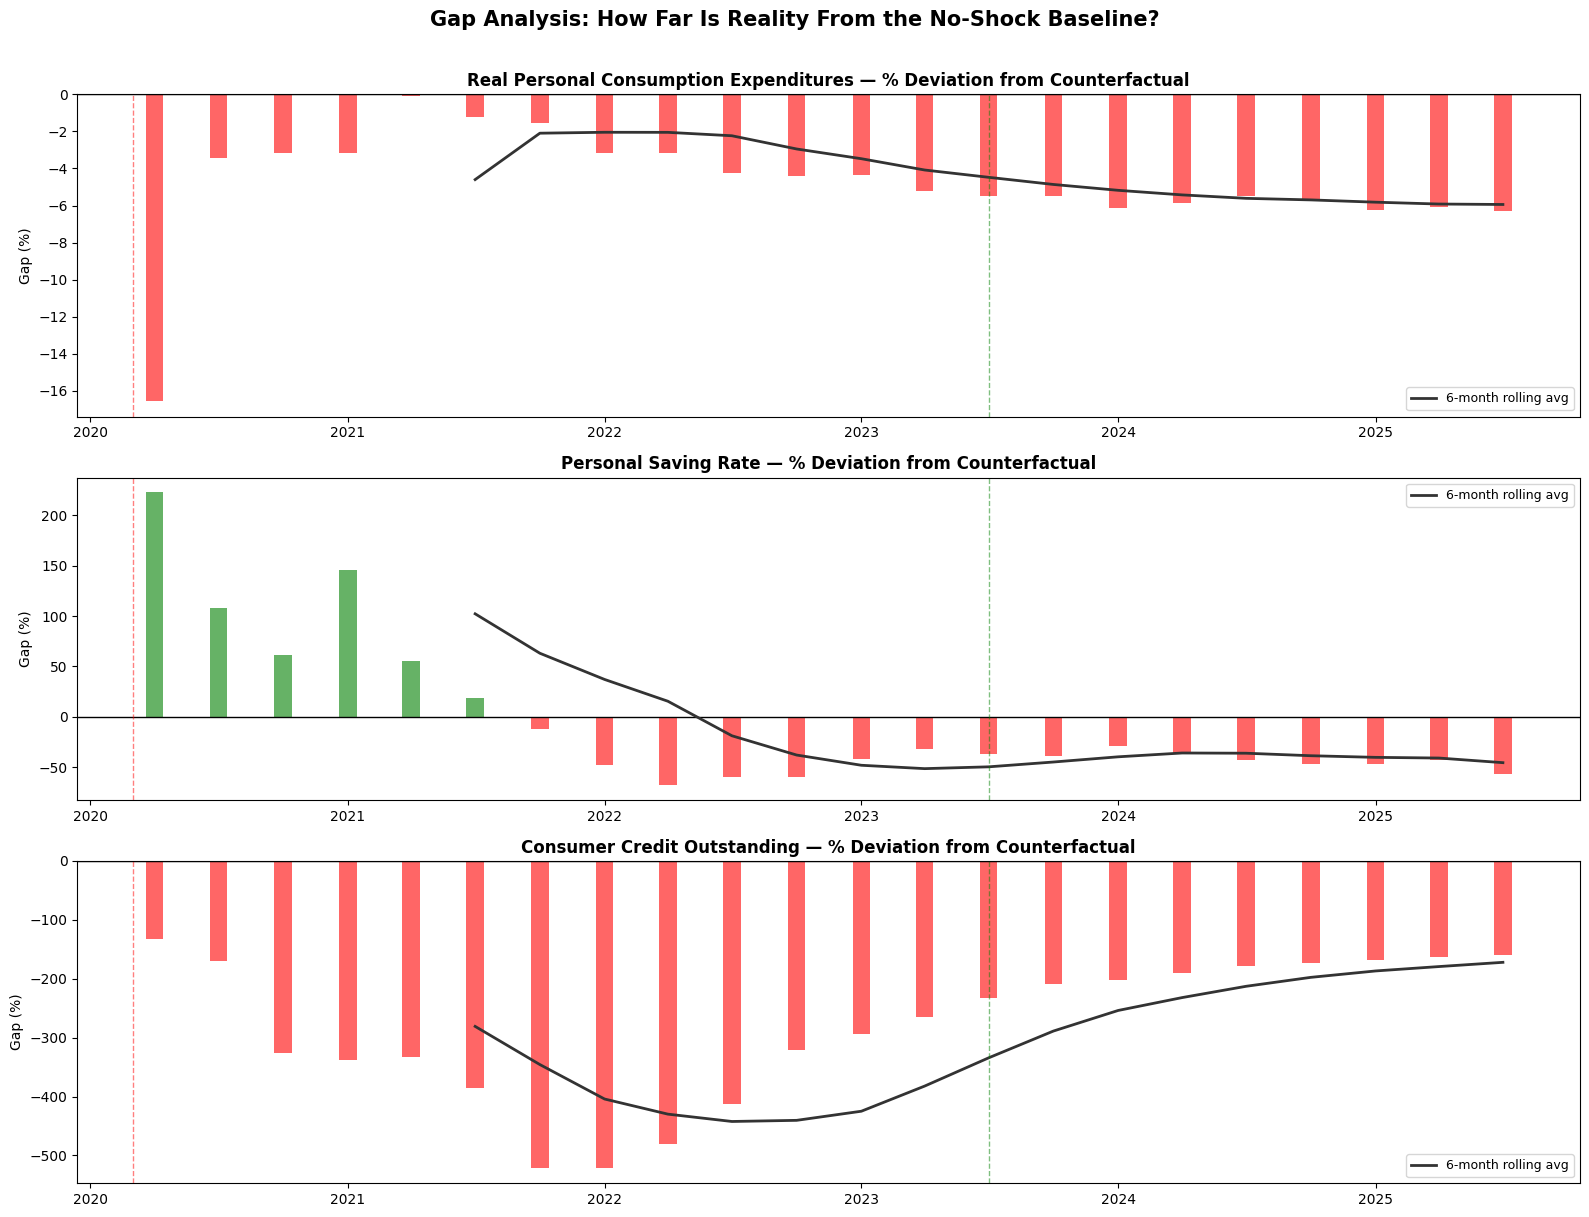

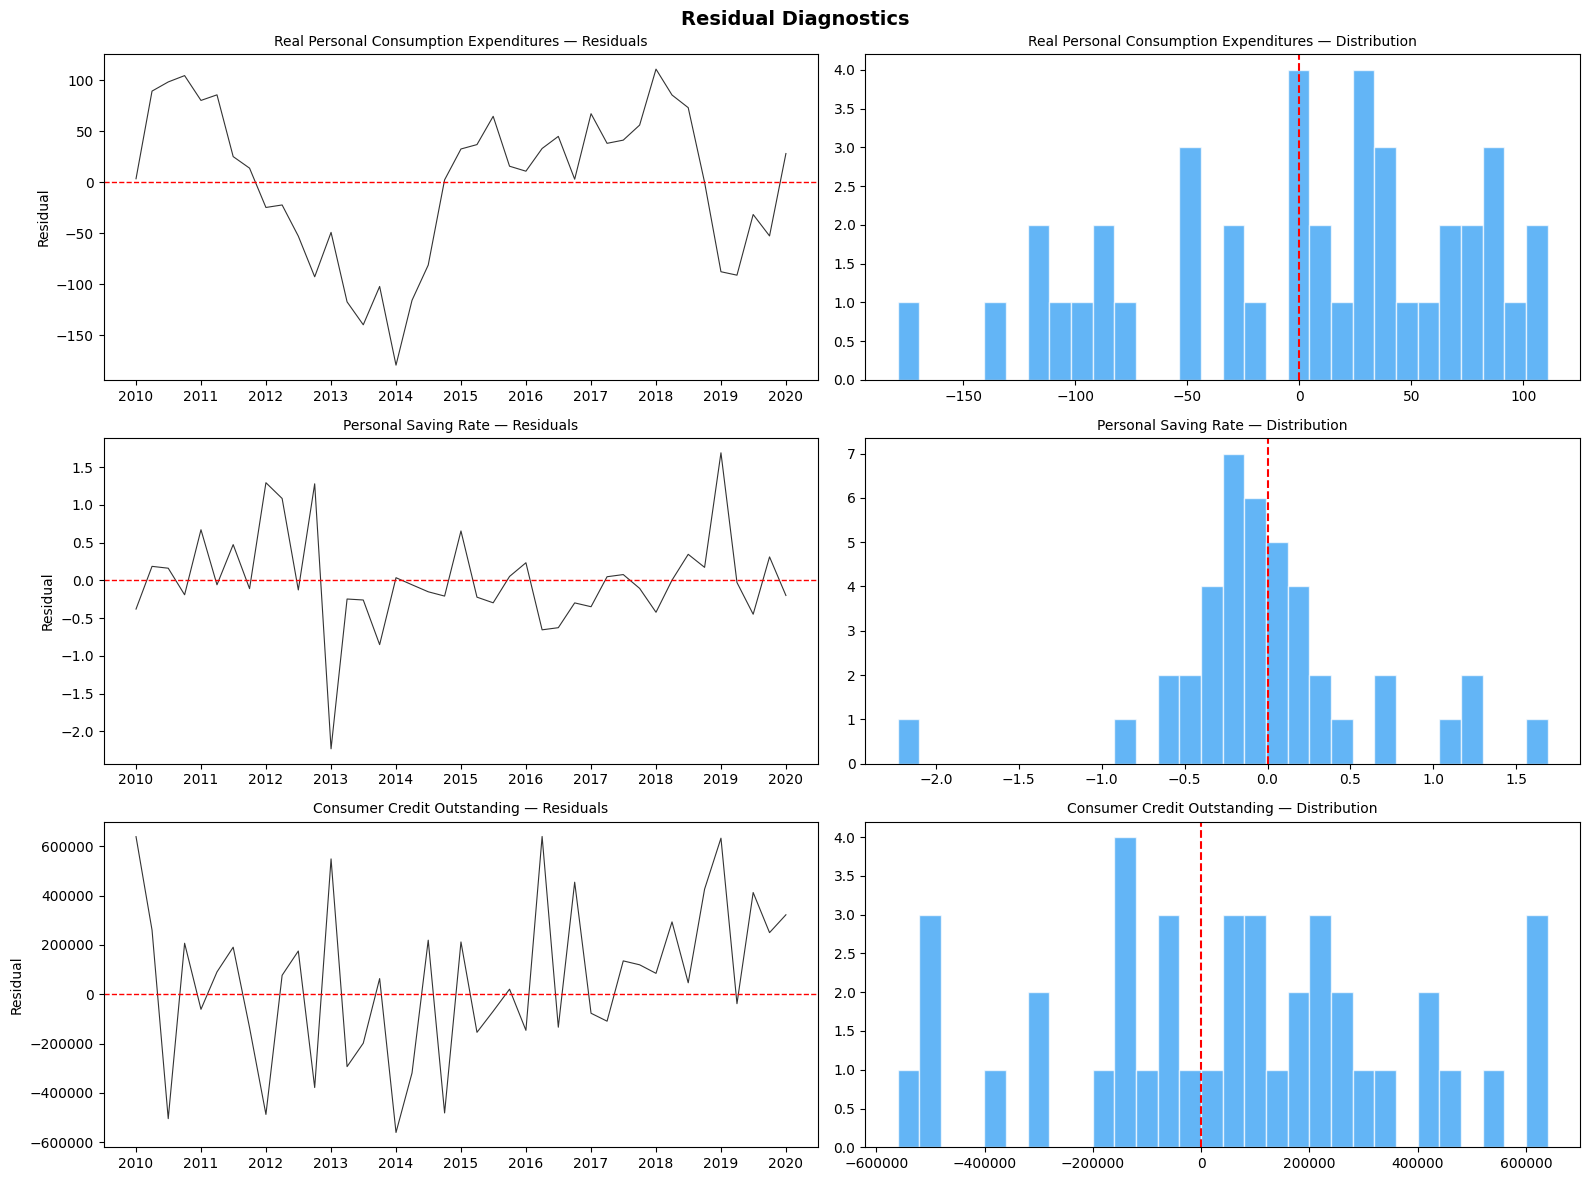

In [76]:
print("Visualization")
plot_counterfactual(models, df_clean, breaks_dict={})
plot_gap_over_time(models)
plot_residual_diagnostics(models)